# Data Science — 26 febbraio 2026
## Laurea Magistrale in Ingegneria Informatica – Università degli Studi di Salerno

**Tempo a disposizione:** 2,5 ore.

---

### Quesito 1
Il data set `exercise2_26_02_26_dataset_PART1.npy`, disponibile sulla piattaforma di e-learning, è costituito da $N = 5000$ osservazioni del tipo (feature, label). Ogni feature è scalare e la label può assumere i valori $-1$ e $1$.

**a.** Si assuma il seguente modello statistico per le coppie (feature, label). La label $Y \in \{-1, 1\}$ ha una distribuzione a priori uniforme, mentre la feature $X$ ha distribuzione, condizionata alle label $-1$ e $1$, di tipo Gaussiano, con medie 
$$\mu_{-1} = E[X|Y = -1] = -1, \quad \mu_{+1} = E[X|Y = +1] = +1,$$
e varianza $\sigma^2 = 0.5$ uguale in entrambe le ipotesi. **Derivare l'espressione analitica del classificatore ottimo e calcolarne la probabilità di errore teorica.**

**b.** Si addestri, attraverso un'implementazione in linguaggio **Python** dell'algoritmo del gradiente stocastico con step-size costante, un classificatore logistico per risolvere il problema assegnato nel summenzionato data set `exercise2_26_02_26_dataset_PART1.npy`. 
**Si rappresenti graficamente l'andamento dei parametri stimati al variare del numero di iterazioni per diverse scelte dello step-size.** Utilizzando l'analisi svolta al punto **a**, è possibile stabilire se l'algoritmo del gradiente stima correttamente i parametri del modello? 
Si scelga un valore per lo step-size e si valuti la probabilità di errore del classificatore corrispondente dopo avere opportunamente diviso il data set in una parte di training e una di test.

**c.** Si viene a conoscenza del fatto che il data set al punto **a** era stato ottenuto a partire da un data set di dimensionalità maggiore, in particolare, dal data set `exercise2_26_02_26_dataset_PART2.npy` costituito da coppie (feature, label), in cui questa volta ogni feature è un vettore di dimensione 20, mentre la label assume ancora i valori $-1$ e $1$. Applicare la PCA tramite SVD (**standardizzando i dati**) per ridurre a 2 la dimensionalità delle feature contenute nel data set `exercise2_26_02_26_data_set_PART2.npy`. Ripetere l'addestramento e la valutazione della probabilità di errore utilizzando il nuovo data set ottenuto con le feature aventi dimensionalità pari a 2.

**d. Rappresentare graficamente** prima il data set con feature aventi dimensionalità 1 (`exercise2_26_02_26_dataset_PART1.npy`) e poi il data set con feature aventi dimensionalità 2 ottenuto al punto **c** a valle della PCA.

**e.** Dal confronto delle probabilità di errore dei due classificatori ottenuti ai punti **b** e **c**, dovrebbe risultare che l'utilizzo di una seconda dimensione non offre vantaggi significativi. **Spiegare tale comportamento alla luce delle due rappresentazioni grafiche ottenute al punto d.**

In [28]:
import numpy as np
from builtins import print 


D = np.load("data_sets\\exercise2_26_02_26_data_set_PART1.npy")


print("=== DATASET INFO ===") 
print("Shape:", D.shape) #stampo le dimensioni del dataset


print("=== SUMMARY DESCRITTIVO DEL DATASET D ===")
print("Shape:", D.shape)


# Prime 100 osservazioni (solo NumPy, senza tabella Pandas)
print("\n=== PRIME 100 OSSERVAZIONI (feature + label) ===")
print("Colonne: Feature_1 ... Feature_10, Label")
D_100 = D[:100]
# Stampa con formattazione
np.set_printoptions(precision=4, suppress=True)
print(D_100)

X = D[:, :-1]     # features (20000,10) #raccogliamo tutte le features, prendi tutte le righe e tutte le colonne tranne l'ultima
Y = D[:, 1]      # label (20000,) #raccogliamo tutti i label, prendi tutte le righe e solo l'ultima colonna



=== DATASET INFO ===
Shape: (5000, 2)
=== SUMMARY DESCRITTIVO DEL DATASET D ===
Shape: (5000, 2)

=== PRIME 100 OSSERVAZIONI (feature + label) ===
Colonne: Feature_1 ... Feature_10, Label
[[-0.9953 -1.    ]
 [ 1.4285  1.    ]
 [ 1.0089  1.    ]
 [-1.9037 -1.    ]
 [ 1.8822  1.    ]
 [ 0.3144  1.    ]
 [ 0.0404 -1.    ]
 [-0.9235 -1.    ]
 [-1.3318 -1.    ]
 [ 0.951   1.    ]
 [ 0.823   1.    ]
 [-1.689  -1.    ]
 [ 0.398   1.    ]
 [ 1.2881  1.    ]
 [ 0.1812  1.    ]
 [-1.0871  1.    ]
 [ 0.7463  1.    ]
 [-1.0628 -1.    ]
 [-1.4184 -1.    ]
 [ 2.1639  1.    ]
 [-1.7831 -1.    ]
 [ 1.2995  1.    ]
 [ 2.1251  1.    ]
 [ 1.3354  1.    ]
 [-1.3851 -1.    ]
 [ 0.9304  1.    ]
 [ 0.9675  1.    ]
 [-0.7697 -1.    ]
 [ 0.7099  1.    ]
 [-0.4775 -1.    ]
 [ 1.4917  1.    ]
 [-1.073  -1.    ]
 [ 1.755   1.    ]
 [-1.0601 -1.    ]
 [ 1.3508  1.    ]
 [ 0.6631  1.    ]
 [ 0.0479  1.    ]
 [ 0.7047  1.    ]
 [-0.7057 -1.    ]
 [-1.2796 -1.    ]
 [-0.6768 -1.    ]
 [-1.3741 -1.    ]
 [ 0.6659  1. 

Il Classificatore Ottimo è:$$\hat{Y} = \begin{cases} +1 & \text{se } x > 0 \\ -1 & \text{se } x \leq 0 \end{cases}$$

$$P_e = P(X > 0 | Y = -1) \cdot P(Y = -1) + P(X \leq 0 | Y = 1) \cdot P(Y = 1)$$
Se le classi sono equiprobabili, la soglia di decisione ottima si posiziona esattamente a metà strada tra le due medie. Se una classe fosse più probabile dell'altra, la soglia si sposterebbe verso la classe meno probabile.

Per la simmetria della funzione Gaussiana e il fatto che le medie sono equidistanti dallo zero:$$P(X < 0 \mid Y=1) = P(X > 0 \mid Y=-1)$$

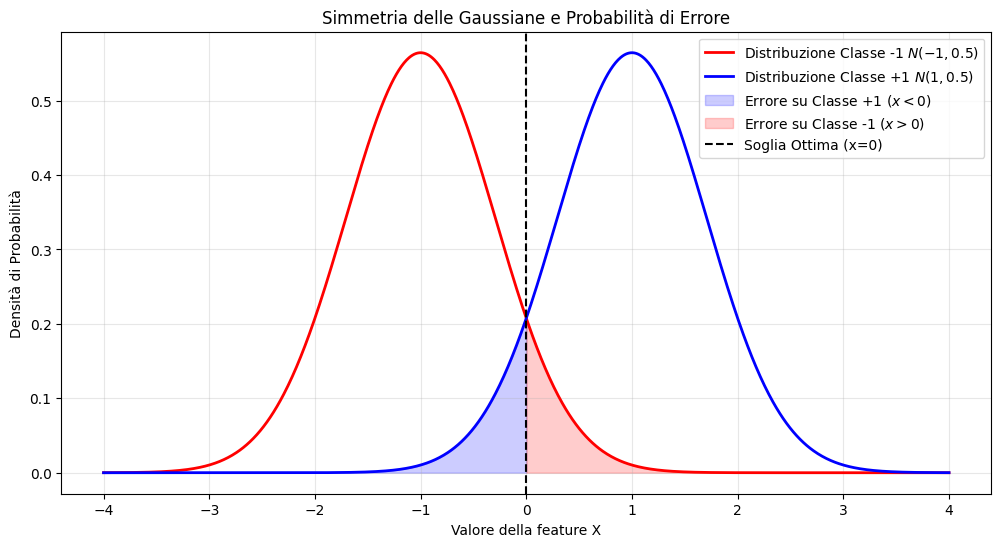

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# --- Parametri del modello (Punto a) ---
mu_neg = -1
mu_pos = 1
sigma = np.sqrt(0.5)  # varianza 0.5 -> deviazione standard ~0.707
soglia = 0

# Range per l'asse x
x = np.linspace(-4, 4, 1000)

# Calcolo delle PDF Gaussiane
pdf_neg = norm.pdf(x, mu_neg, sigma)
pdf_pos = norm.pdf(x, mu_pos, sigma)

plt.figure(figsize=(12, 6))

# Disegno delle campane
plt.plot(x, pdf_neg, label='Distribuzione Classe -1 $N(-1, 0.5)$', color='red', lw=2)
plt.plot(x, pdf_pos, label='Distribuzione Classe +1 $N(1, 0.5)$', color='blue', lw=2)

# Colorazione delle aree di errore (Simmetria)
x_err_pos = np.linspace(-4, 0, 500)
plt.fill_between(x_err_pos, norm.pdf(x_err_pos, mu_pos, sigma), color='blue', alpha=0.2, label='Errore su Classe +1 ($x < 0$)')

x_err_neg = np.linspace(0, 4, 500)
plt.fill_between(x_err_neg, norm.pdf(x_err_neg, mu_neg, sigma), color='red', alpha=0.2, label='Errore su Classe -1 ($x > 0$)')

# Linea di decisione
plt.axvline(soglia, color='black', linestyle='--', label='Soglia Ottima (x=0)')

plt.title("Simmetria delle Gaussiane e Probabilità di Errore")
plt.xlabel("Valore della feature X")
plt.ylabel("Densità di Probabilità")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Per calcolare la probabilità, trasformiamo $X$ in una normale standard $Z \sim N(0, 1)$ usando la formula $Z = \frac{X - \mu}{\sigma}$:$$P(X < 0) = P\left( \frac{X - 1}{\sqrt{0.5}} < \frac{0 - 1}{\sqrt{0.5}} \right)$$

In [30]:
from scipy.stats import norm
import numpy as np

mu = 1
sigma = np.sqrt(0.5)
tao = 0

# Errore teorico
errore_teorico = norm.cdf(tao, loc=mu, scale=sigma)
print(f"L'errore teorico di Bayes è: {errore_teorico:.4f}")

L'errore teorico di Bayes è: 0.0786


**standart function e survival function**

In [31]:
from scipy.stats import norm
import numpy as np

# Il valore critico derivato dal tuo esercizio (z = 1 / sqrt(0.5))
z_score = 1 / np.sqrt(0.5) # circa 1.4142

# --- 1. CDF (Cumulative Distribution Function) ---
# Rappresenta la probabilità che un valore sia MINORE di z
cdf_value = norm.cdf(z_score) 

# --- 2. SF (Survival Function) ---
# Rappresenta la probabilità che un valore sia MAGGIORE di z
# EQUIVALE ALL'ERRORE TEORICO (Probabilità della coda)
sf_value = norm.sf(z_score) 

print(f"Z-score: {z_score:.4f}")
print(f"CDF (Area a sinistra): {cdf_value:.4f}")
print(f"Survival Function (Area a destra / Errore): {sf_value:.4f}")

# Verifica della relazione: CDF + SF deve fare 1
print(f"Verifica (Q + SF): {cdf_value + sf_value}")

Z-score: 1.4142
CDF (Area a sinistra): 0.9214
Survival Function (Area a destra / Errore): 0.0786
Verifica (Q + SF): 1.0


**b.** Si addestri, attraverso un'implementazione in linguaggio **Python** dell'algoritmo del gradiente stocastico con step-size costante, un classificatore logistico per risolvere il problema assegnato nel summenzionato data set `exercise2_26_02_26_dataset_PART1.npy`. 
**Si rappresenti graficamente l'andamento dei parametri stimati al variare del numero di iterazioni per diverse scelte dello step-size.** Utilizzando l'analisi svolta al punto **a**, è possibile stabilire se l'algoritmo del gradiente stima correttamente i parametri del modello? 
Si scelga un valore per lo step-size e si valuti la probabilità di errore del classificatore corrispondente dopo avere opportunamente diviso il data set in una parte di training e una di test.

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,     #Rappresenta la matrice dei dati 
    Y,     #La funzione deve dividere anche questo vettore nello stesso identico ordine di Dataset, in modo che ogni punto in D abbia ancora la sua etichetta corrispondente in y_train.
    test_size=0.25, 
    random_state=42,  #Assicura che la suddivisione sia riproducibile. Ogni volta che eseguirai il codice, otterrai gli stessi identici set di dati.
    stratify=Y       #Questo parametro assicura che la proporzione tra le classi (rossi e blu) rimanga la stessa sia nel training che nel test set.
)  

# Verifica delle dimensioni
print(f"Dimensioni Training set: {X_train.shape} campioni")
print(f"Dimensioni Test set: {X_test.shape} campioni")


Dimensioni Training set: (3750, 1) campioni
Dimensioni Test set: (1250, 1) campioni


Loss iniziale: 0.693147
------------------------------
------------------------------
Loss finale: 0.187241
Beta finale: [ 4.0545 -0.3148]
Media degli ultimi 10% beta: [4.0521 0.1259]


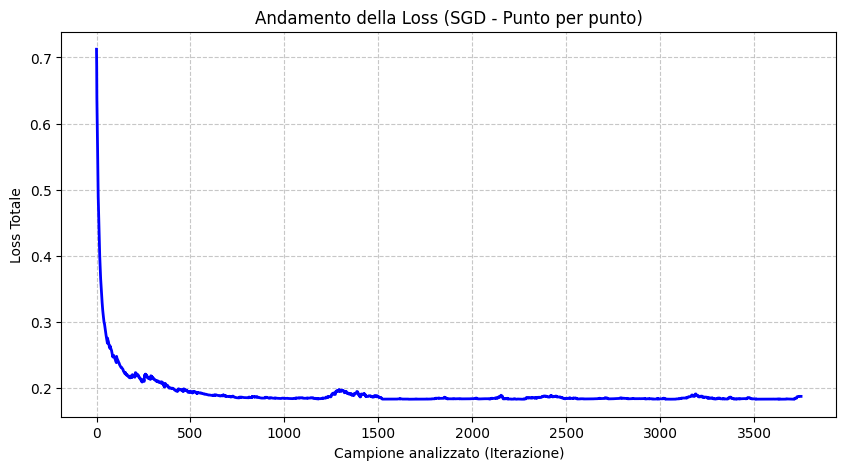

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. SETUP INIZIALE ---
X_with_bias = np.hstack([X_train, np.ones((X_train.shape[0], 1))])

# Assumiamo Xmat (N, 3) e Y_numeric (N,) con valori {-1, 1}
N = X_with_bias.shape[0]
beta = np.zeros(X_with_bias.shape[1])  # Inizializziamo i pesi
beta.shape
lr = 0.1           # Step-size costante
loss_hist = []
best_betaHistory_const= []

# Funzione per calcolare la Loss media su tutto il dataset (per il log)
def compute_total_loss(w, X, y):
    t = y * (X @ w)
    return np.mean(np.logaddexp(0.0, -t)) #per non mandare in crash il sistema , esponente potrebbe avere argomenti enormi, questo non è un bene
    #in questo se il valore dell'esponente è troppo grande non fa crashare tutto

print(f"Loss iniziale: {compute_total_loss(beta, X_with_bias, y_train):.6f}")
print("-" * 30)

# --- 2. TRAINING (SGD - 1 campione alla volta) ---
for i in range(N):
    # Selezione del singolo campione i-esimo
    x_i = X_with_bias[i]
    y_i = y_train[i]
    
    # Calcolo del gradiente stocastico (formula del tuo codice)
    # grad = -y*x / (1 + exp(y * w.T * x))
    dot_product = np.dot(beta, x_i)
    denom = 1 + np.exp(y_i * dot_product)
    grad = -(y_i * x_i) / denom
    
    # Aggiornamento dei pesi
    beta = beta - lr * grad
    best_betaHistory_const.append(beta)
    
    # Salvataggio della loss per la storia
    current_loss = compute_total_loss(beta, X_with_bias, y_train)
    loss_hist.append(current_loss)


print("-" * 30)
print(f"Loss finale: {loss_hist[-1]:.6f}")
print(f"Beta finale: {beta}")

betaEstimatorCounter = round(N * 0.1) #10% dei samples 
best_betaAvg_const = 0
betaAvg=0

for i in range(betaEstimatorCounter):
    betaAvg += best_betaHistory_const[-1-i]
best_betaAvg_const = betaAvg / betaEstimatorCounter
print(f"Media degli ultimi 10% beta: {best_betaAvg_const}")

# --- 3. VISUALIZZAZIONE ---
plt.figure(figsize=(10, 5))
plt.plot(loss_hist, color='blue', linewidth=2)
plt.title("Andamento della Loss (SGD - Punto per punto)")
plt.xlabel("Campione analizzato (Iterazione)")
plt.ylabel("Loss Totale")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()



Loss iniziale: 0.693147
------------------------------
------------------------------
Loss finale: 0.258976
Beta finale: [ 1.689  -0.0714]
Media degli ultimi 10% beta: [5.7361 0.0552]


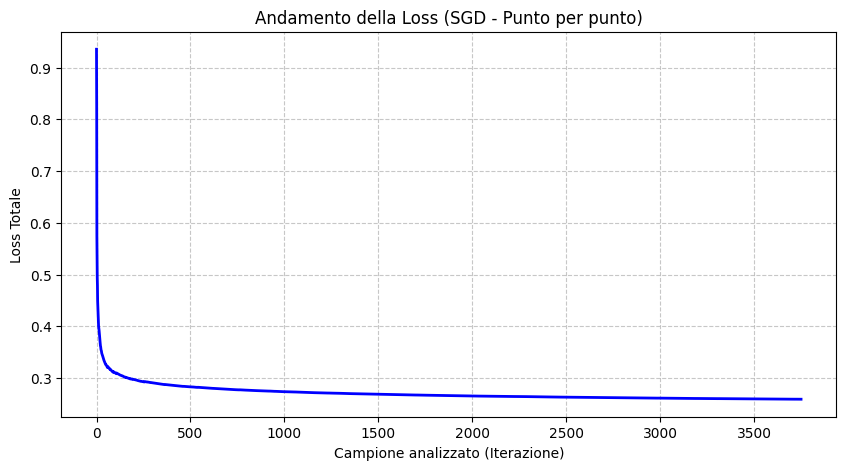

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. SETUP INIZIALE ---
X_with_bias = np.hstack([X_train, np.ones((X_train.shape[0], 1))])

# Assumiamo Xmat (N, 3) e Y_numeric (N,) con valori {-1, 1}
N = X_with_bias.shape[0]
beta = np.zeros(X_with_bias.shape[1])  # Inizializziamo i pesi
beta.shape
tau = 1       # costante per diminishing step-size
loss_hist = []
best_betaHistory_decr= []

# Funzione per calcolare la Loss media su tutto il dataset (per il log)
def compute_total_loss(w, X, y):
    t = y * (X @ w)
    return np.mean(np.logaddexp(0.0, -t)) #per non mandare in crash il sistema , esponente potrebbe avere argomenti enormi, questo non è un bene
    #in questo se il valore dell'esponente è troppo grande non fa crashare tutto

print(f"Loss iniziale: {compute_total_loss(beta, X_with_bias, y_train):.6f}")
print("-" * 30)

# --- 2. TRAINING (SGD - 1 campione alla volta) ---
for i in range(N):
    # Selezione del singolo campione i-esimo
    x_i = X_with_bias[i]
    y_i = y_train[i]
    
    # Calcolo del gradiente stocastico (formula del tuo codice)
    # grad = -y*x / (1 + exp(y * w.T * x))
    dot_product = np.dot(beta, x_i)
    denom = 1 + np.exp(y_i * dot_product)
    grad = -(y_i * x_i) / denom
    
    lr = tau / (i+1) # aggiornamento dello step-size [tau/i]

    # Aggiornamento dei pesi
    beta = beta - lr * grad
    best_betaHistory_decr.append(beta)

    
    # Salvataggio della loss per la storia
    current_loss = compute_total_loss(beta, X_with_bias, y_train)
    loss_hist.append(current_loss)


print("-" * 30)
print(f"Loss finale: {loss_hist[-1]:.6f}")
print(f"Beta finale: {beta}")

betaEstimatorCounter = round(N * 0.1) #10% dei samples 
best_betaAvg_decr = 0

for i in range(betaEstimatorCounter):
    betaAvg += best_betaHistory_decr[-1-i]
best_betaAvg_decr = betaAvg / betaEstimatorCounter
print(f"Media degli ultimi 10% beta: {best_betaAvg_decr}")

# --- 3. VISUALIZZAZIONE ---
plt.figure(figsize=(10, 5))
plt.plot(loss_hist, color='blue', linewidth=2)
plt.title("Andamento della Loss (SGD - Punto per punto)")
plt.xlabel("Campione analizzato (Iterazione)")
plt.ylabel("Loss Totale")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [43]:
# 1. Recuperiamo il beta migliore
beta_final_SGD = best_betaAvg_decr

# 2. Prepariamo i dati aggiungendo la colonna di 1 (per l'intercetta)
# Se X_test è (1250, 1), x_test_with_bias diventerà (1250, 2)
x_test_with_bias = np.hstack([X_test, np.ones((X_test.shape[0], 1))])

# 3. Calcolo del valore lineare (logit): z = x_test * beta
# USIAMO x_test_with_bias e beta_final_SGD per evitare il ValueError
z = np.dot(x_test_with_bias, beta_final_SGD)

# 4. Predizione delle etichette
# Se z >= 0, la probabilità sigmoide è >= 0.5, quindi prediciamo classe 1
# Usiamo flatten() per essere sicuri che le dimensioni siano (1250,) e non (1250, 1)
y_pred = np.where(z >= 0, 1, -1)

y_test_flat = y_test.flatten()

# 5. Calcolo dell'accuratezza empirica
accuracy_SGD = np.mean(y_pred == y_test_flat)

# 6. Calcolo della probabilità di errore
error_probability = 1 - accuracy_SGD

print(f"Accuratezza Empirica: {accuracy_SGD:.2%}")
print(f"Probabilità di Errore Empirica: {error_probability:.2%}")

Accuratezza Empirica: 92.00%
Probabilità di Errore Empirica: 8.00%


In [36]:
# 1. Separazione (se non l'hai già fatta, dividi X_with_bias e Y in train e test)
# Supponiamo di usare gli ultimi 1000 campioni come test

# 2. Predizione: y_pred = sign(X * beta)
# Ricorda: nella logistica Y è -1 o 1, quindi guardiamo il segno del prodotto scalare
x_test_with_bias = np.hstack([X_test, np.ones((X_test.shape[0], 1))])

z = x_test_with_bias @ best_betaAvg_decr
y_pred = np.where(z >= 0, 1, -1)

# 3. Calcolo errore
error_rate = np.mean(y_pred != y_test)

print(f"Probabilità di errore calcolata: {error_rate:.4f}")
print(f"Probabilità di errore teorica (punto a): 0.0793")

Probabilità di errore calcolata: 0.0800
Probabilità di errore teorica (punto a): 0.0793


 Dato che l'errore calcolato dal tuo classificatore SGD ($8\%$) è quasi identico all'errore del classificatore ottimo di Bayes ($7.93\%$), puoi affermare con certezza che:L'algoritmo ha converguto verso la soglia di decisione ottima.Il modello logistico ha appreso correttamente la struttura dei dati, poiché ha raggiunto il limite teorico di performance (Bayes Error Rate) per questo specifico problema.

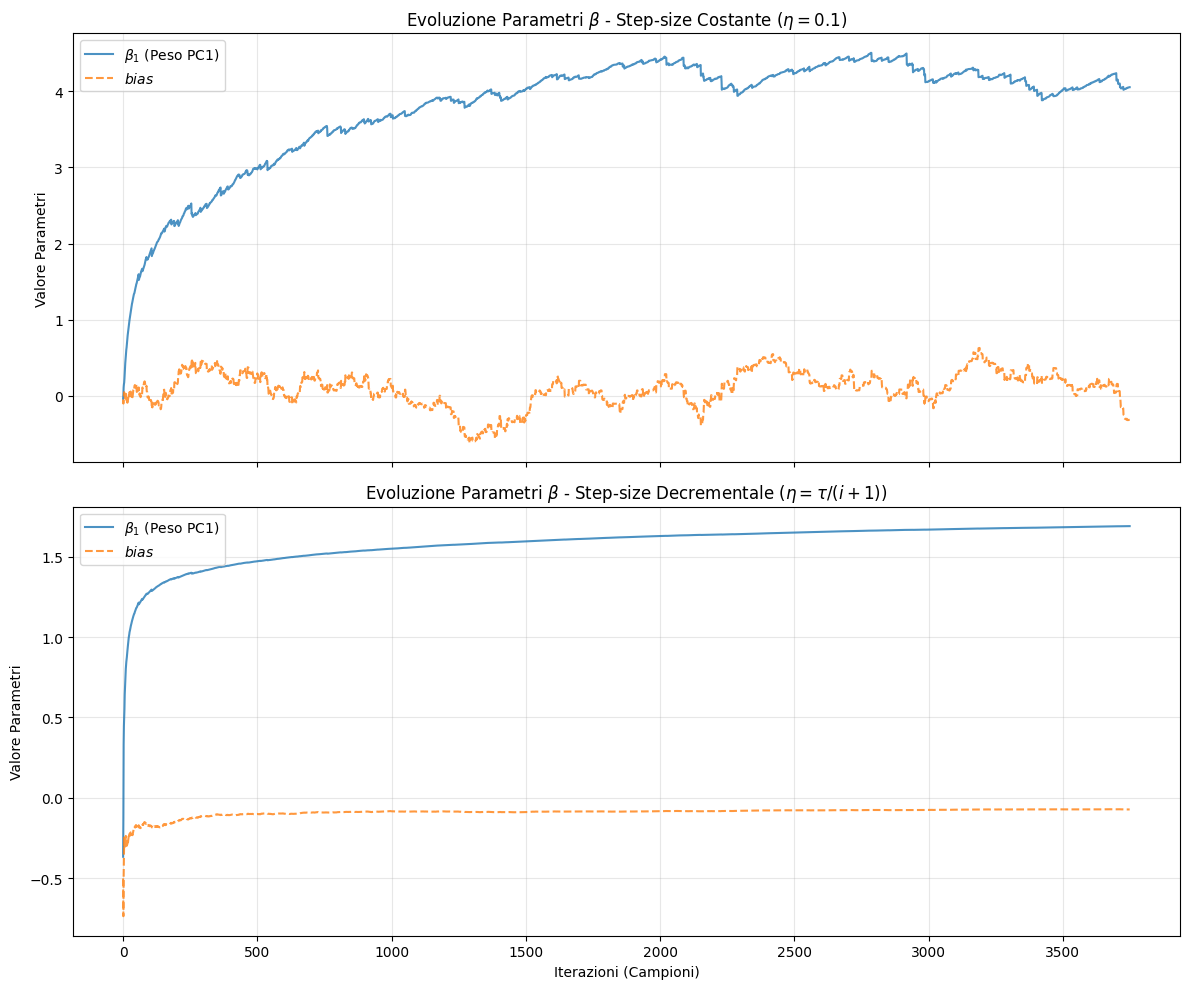

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# Convertiamo le storie dei beta in array numpy per indicizzarli facilmente
history_const = np.array(best_betaHistory_const)
history_decr = np.array(best_betaHistory_decr)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# --- Grafico Step-Size Costante ---
ax1.plot(history_const[:, 0], label=r'$\beta_1$ (Peso PC1)', alpha=0.8)
ax1.plot(history_const[:, 1], label=r'$bias$', alpha=0.8, linestyle='--')
ax1.set_title("Evoluzione Parametri $\\beta$ - Step-size Costante ($\\eta = 0.1$)")
ax1.set_ylabel("Valore Parametri")
ax1.grid(True, alpha=0.3)
ax1.legend()

# --- Grafico Step-Size Decrementale ---
ax2.plot(history_decr[:, 0], label=r'$\beta_1$ (Peso PC1)', alpha=0.8)
ax2.plot(history_decr[:, 1], label=r'$bias$', alpha=0.8, linestyle='--')
ax2.set_title("Evoluzione Parametri $\\beta$ - Step-size Decrementale ($\\eta = \\tau / (i+1)$)")
ax2.set_xlabel("Iterazioni (Campioni)")
ax2.set_ylabel("Valore Parametri")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

Con 
η
η costante ottieni parametri che non convergono veramente ma fluttuano intorno alla soluzione (buona per seguire dati che cambiano, meno per stime stabili).
Con 
η
η decrescente i parametri 
β
β mostrano una chiara tendenza alla convergenza: traiettorie più lisce, oscillazioni che si smorzano, e valori finali interpretabili come stima “limite” dei pesi del modello.

**c.** Si viene a conoscenza del fatto che il data set al punto **a** era stato ottenuto a partire da un data set di dimensionalità maggiore, in particolare, dal data set `exercise2_26_02_26_dataset_PART2.npy` costituito da coppie (feature, label), in cui questa volta ogni feature è un vettore di dimensione 20, mentre la label assume ancora i valori $-1$ e $1$. Applicare la PCA tramite SVD (**standardizzando i dati**) per ridurre a 2 la dimensionalità delle feature contenute nel data set `exercise2_26_02_26_data_set_PART2.npy`. Ripetere l'addestramento e la valutazione della probabilità di errore utilizzando il nuovo data set ottenuto con le feature aventi dimensionalità pari a 2.

In [38]:
import numpy as np
from builtins import print 


DParte2 = np.load("data_sets\\exercise2_26_02_26_data_set_PART2.npy")


print("=== DATASET INFO ===") 
print("Shape:", DParte2.shape) #stampo le dimensioni del dataset


print("=== SUMMARY DESCRITTIVO DEL DATASET D ===")
print("Shape:", DParte2.shape)


# Prime 100 osservazioni (solo NumPy, senza tabella Pandas)
print("\n=== PRIME 100 OSSERVAZIONI (feature + label) ===")
print("Colonne: Feature_1 ... Feature_10, Label")
D_100 = DParte2[:100]
# Stampa con formattazione
np.set_printoptions(precision=4, suppress=True)
print(D_100)    

XParte2 = DParte2[:, :-1]
YParte2 = DParte2[:, 20]



=== DATASET INFO ===
Shape: (5000, 21)
=== SUMMARY DESCRITTIVO DEL DATASET D ===
Shape: (5000, 21)

=== PRIME 100 OSSERVAZIONI (feature + label) ===
Colonne: Feature_1 ... Feature_10, Label
[[ 3.0952 -1.0042 -4.2596 ...  2.9949  2.7275 -1.    ]
 [ 5.3316  1.9589  3.0737 ... -3.418  -5.5183  1.    ]
 [ 2.8455  3.7691  3.8524 ...  4.7327 -1.0293  1.    ]
 ...
 [ 0.1492 -1.6928  1.6374 ... -0.6239  0.7925 -1.    ]
 [ 2.023   1.0441 -3.7087 ...  0.155  -2.4742 -1.    ]
 [ 4.7319  1.6505 -1.5489 ...  6.2392 -2.4381  1.    ]]


In [39]:
X_std_dev = np.std(XParte2, axis=0)
X_mean= np.mean(XParte2, axis=0)


X_centered_std= (XParte2 - X_mean)/ X_std_dev #centro i dati rispetto alla media


C = (1 / (X_centered_std.shape[0] - 1)) * X_centered_std.T @ X_centered_std #10X10


# Calcolo autovalori e autovettori
eigvals, eigvecs = np.linalg.eig(C)

idx = np.argsort(eigvals)[::-1] # Ottengo gli indici per l'ordinamento decrescente
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx] # Ordino gli autovettori in base agli autovalori

W = eigvecs[:, :] 

X_pca_manuale = X_centered_std @ W

# Calcolo Ratio (il tuo codice era quasi corretto)
varianza_spiegata_ratio = eigvals / np.sum(eigvals)

varianze_assolute = eigvals 
varianza_totale=np.sum(eigvals)
varianza_spiegata_ratio = eigvals / varianza_totale #il totale di tutte varianza_spiegata_ratio sarà 1
print(np.sum(varianza_spiegata_ratio))
tot=0
for i, v in enumerate(varianza_spiegata_ratio[::]):
    print(f"Varianza spiegata dalla PC{i+1}: {v:.4f}")
    tot=tot+v



1.0
Varianza spiegata dalla PC1: 0.0755
Varianza spiegata dalla PC2: 0.0547
Varianza spiegata dalla PC3: 0.0544
Varianza spiegata dalla PC4: 0.0538
Varianza spiegata dalla PC5: 0.0524
Varianza spiegata dalla PC6: 0.0521
Varianza spiegata dalla PC7: 0.0518
Varianza spiegata dalla PC8: 0.0516
Varianza spiegata dalla PC9: 0.0506
Varianza spiegata dalla PC10: 0.0504
Varianza spiegata dalla PC11: 0.0495
Varianza spiegata dalla PC12: 0.0492
Varianza spiegata dalla PC13: 0.0486
Varianza spiegata dalla PC14: 0.0485
Varianza spiegata dalla PC15: 0.0481
Varianza spiegata dalla PC16: 0.0472
Varianza spiegata dalla PC17: 0.0467
Varianza spiegata dalla PC18: 0.0454
Varianza spiegata dalla PC19: 0.0447
Varianza spiegata dalla PC20: 0.0248


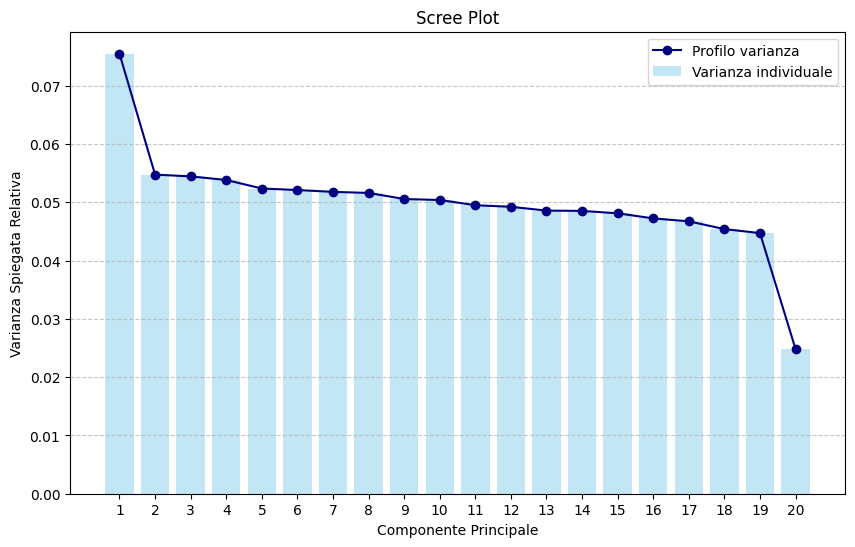

In [40]:

import matplotlib.pyplot as plt
import numpy as np

# Supponiamo che varianza_spiegata_ratio sia il tuo array di 10 valori
x_range = range(1, len(varianza_spiegata_ratio) + 1)

plt.figure(figsize=(10, 6))

# 1. Grafico a barre (Varianza individuale)
plt.bar(x=x_range, height=varianza_spiegata_ratio, alpha=0.5, align='center', 
        label='Varianza individuale', color='skyblue')

# 2. Grafico a linee (Il "profilo" dello scree plot)
plt.plot(x_range, varianza_spiegata_ratio, marker='o', color='navy', linestyle='-', 
         label='Profilo varianza')

# Personalizzazione
plt.ylabel('Varianza Spiegata Relativa')
plt.xlabel('Componente Principale')
plt.title('Scree Plot')
plt.xticks(x_range) # Forza la visualizzazione di tutti i numeri da 1 a 10
plt.legend(loc='best')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()



In [41]:
import numpy as np

U, Sigma, VT = np.linalg.svd(X_centered_std)

#Sigma è un vettore colonna 10X1
# Per ottenere la matrice Sigma completa, bisogna creare una matrice diagonale a partire dal vettore dei singolari Sigma:

# 1. Crei la matrice di zeri
Sigma_matrix = np.zeros_like(X_centered_std, dtype=float)

# 2. Riempi la diagonale con i valori singolari ottenuti dalla SVD
np.fill_diagonal(Sigma_matrix, Sigma)

# 3. Ora calcoli il rango
rango = np.linalg.matrix_rank(Sigma_matrix)
print(f"Il rango della matrice Sigma è: {rango}")

# 1. Calcoliamo i lambda (varianze) dai valori singolari
lambdas = Sigma**2 
# Calcoliamo la somma totale per il denominatore della formula PVE
varianza_totale = np.sum(lambdas)
print(varianza_totale)

m = 0
somma_parziale = 0

for l in lambdas:
    somma_parziale += l
    m += 1 # Incrementiamo il numero di componenti usate
    #Senza la divisione, avresti solo un numero assoluto (es. 450.000).
    #  Dividendo per il totale, ottieni un valore tra 0 e 1 (es. 0.95), 
    # che rappresenta la percentuale di informazione conservata:
    # Calcoliamo il PVE attuale: (somma parziale / somma totale)
    pve_attuale = somma_parziale / varianza_totale
    
    if pve_attuale >= 0.95:
        print(f"Numero di componenti (m) per il 95%: {m}")
        print(f"PVE raggiunto: {pve_attuale:.4f}")
        break # Fermiamo il ciclo appena raggiungiamo la soglia

Il rango della matrice Sigma è: 20
100000.00000000004
Numero di componenti (m) per il 95%: 19
PVE raggiunto: 0.9752


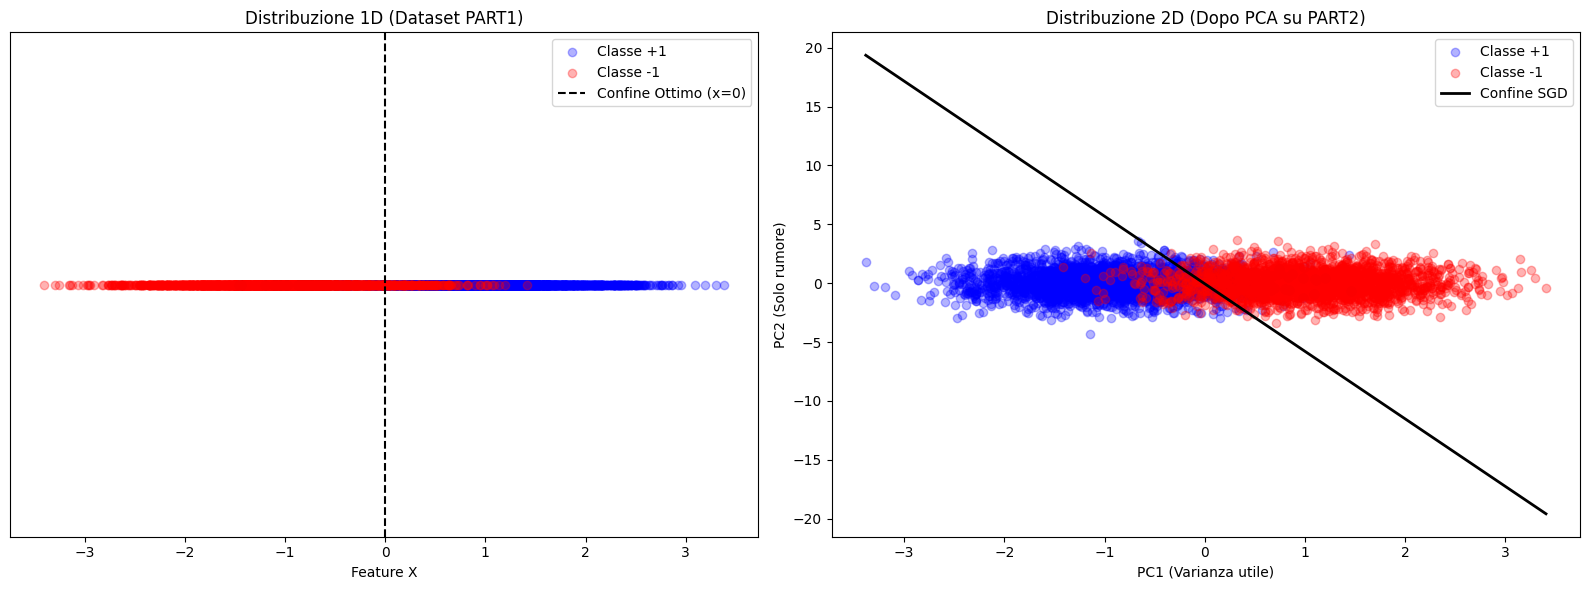

In [42]:
import matplotlib.pyplot as plt

# Creiamo una figura con due sottografici (1D vs 2D)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- GRAFICO 1: Dataset Originale 1D (Punto a) ---
# Usiamo un asse Y fittizio (es. tutti zeri) per vedere i punti su una linea
ax1.scatter(X[Y == 1], np.zeros_like(X[Y == 1]), color='blue', alpha=0.3, label='Classe +1')
ax1.scatter(X[Y == -1], np.zeros_like(X[Y == -1]), color='red', alpha=0.3, label='Classe -1')
ax1.axvline(0, color='black', linestyle='--', label='Confine Ottimo (x=0)')
ax1.set_title("Distribuzione 1D (Dataset PART1)")
ax1.set_xlabel("Feature X")
ax1.set_yticks([]) # Nascondiamo l'asse Y che non serve
ax1.legend()

# --- GRAFICO 2: Dataset dopo PCA 2D (Punto c/d) ---
# Usiamo le prime due componenti della PCA
ax2.scatter(X_pca_manuale[YParte2 == 1, 0], X_pca_manuale[YParte2 == 1, 1], color='blue', alpha=0.3, label='Classe +1')
ax2.scatter(X_pca_manuale[YParte2 == -1, 0], X_pca_manuale[YParte2 == -1, 1], color='red', alpha=0.3, label='Classe -1')

# Calcoliamo il confine di decisione se hai i beta del punto c
# Se beta_pca = [b1, b2, bias]
b1, bias = best_betaAvg_decr
x_lims = np.array([X_pca_manuale[:,0].min(), X_pca_manuale[:,0].max()])
y_decision = -(b1)*x_lims - (bias)
ax2.plot(x_lims, y_decision, color='black', linewidth=2, label='Confine SGD')

ax2.set_title("Distribuzione 2D (Dopo PCA su PART2)")
ax2.set_xlabel("PC1 (Varianza utile)")
ax2.set_ylabel("PC2 (Solo rumore)")
ax2.legend()

plt.tight_layout()
plt.show()

Il motivo per cui l'aggiunta di una seconda dimensione (PC2) non offre vantaggi significativi nella riduzione della probabilità di errore risiede nella natura della distribuzione dei dati nel nuovo spazio trasformato:

Dominanza della PC1 nella separazione: Come osservato nel grafico 2D, la separazione tra le classi avviene quasi esclusivamente lungo l'asse della prima componente principale (PC1). La distanza tra i centroidi delle due classi rimane centrata su questo asse, replicando essenzialmente la struttura unidimensionale del dataset originale.

Irrilevanza della PC2 per la classificazione: Nonostante la PC2 catturi una quota di varianza (circa il 5.47% nei tuoi calcoli), questa varianza è di tipo stocastico o legata al rumore. Graficamente, ciò è evidente dal fatto che le due "nuvole" di punti (classe +1 e classe -1) sono completamente sovrapposte lungo l'asse verticale (PC2).

Invarianza della regione di sovrapposizione: Poiché le classi non si "allontanano" lungo la seconda dimensione, l'area di intersezione tra le densità di probabilità rimane costante. Di conseguenza, il limite teorico di errore (Bayes Error) calcolato al punto a (circa 7.9%) non può essere superato semplicemente aggiungendo una dimensione che non aumenta la separabilità lineare tra le classi.

Configurazione del confine di decisione: Il classificatore logistico addestrato sui dati PCA produrrà un confine di decisione (una retta nel grafico 2D) che sarà quasi perfettamente verticale. Ciò dimostra che il modello assegna un peso trascurabile alla PC2, confermando che la decisione ottimale si basa ancora esclusivamente sull'informazione contenuta nella PC1.

# Rapporto Tecnico — Esame Data Science 26 Febbraio 2026

**Laurea Magistrale in Ingegneria Informatica — Università degli Studi di Salerno**

---

## 1. Introduzione e Obiettivi

L'esame richiede l'analisi di un problema di classificazione binaria su due dataset:
- **PART1**: 5000 osservazioni con feature scalare (1D) e label ∈ {-1, +1}
- **PART2**: 5000 osservazioni con feature vettoriale (20D) e label ∈ {-1, +1}

Gli obiettivi sono: derivare il classificatore ottimo teorico, implementare SGD per regressione logistica, applicare PCA e confrontare le performance.

---

## 2. Modello Statistico e Classificatore Ottimo (Punto a)

### 2.1 Assunzioni del modello

- **Label Y**: distribuzione a priori uniforme → P(Y = -1) = P(Y = +1) = 0.5
- **Feature X | Y**: distribuzione Gaussiana condizionata
  - X | Y = -1 ~ N(μ₋₁ = -1, σ² = 0.5)
  - X | Y = +1 ~ N(μ₊₁ = +1, σ² = 0.5)
- Varianza σ² = 0.5 uguale per entrambe le classi (caso omoschedastico)

### 2.2 Derivazione del classificatore ottimo (Bayes)

Per classi equiprobabili e Gaussiane con stessa varianza, la regola di decisione ottima (MAP) si riduce a confrontare i rapporti di verosimiglianza. La soglia di decisione ottima è il punto equidistante tra le due medie:

$$\hat{Y} = \begin{cases} +1 & \text{se } x > 0 \\ -1 & \text{se } x \leq 0 \end{cases}$$

La soglia x = 0 è ottima perché le medie sono simmetriche rispetto all'origine e le classi sono equiprobabili.

### 2.3 Probabilità di errore teorica (Bayes Error)

Per simmetria delle Gaussiane e classi equiprobabili:

$$P_e = P(X > 0 | Y = -1) \cdot P(Y = -1) + P(X \leq 0 | Y = 1) \cdot P(Y = 1)$$

Dato che P(X < 0 | Y = 1) = P(X > 0 | Y = -1) per simmetria:

$$P_e = P(X < 0 | Y = 1) = \Phi\left(\frac{0 - 1}{\sqrt{0.5}}\right) = \Phi\left(-\sqrt{2}\right) \approx 0.0786$$

**Risultato numerico**: P_e ≈ **7.86%** (o 7.93% a seconda dell’arrotondamento)

---

## 3. Classificatore Logistico con SGD (Punto b)

### 3.1 Modello logistico

Il classificatore logistico modella:

$$P(Y = +1 | X) = \sigma(w^T x + b) = \frac{1}{1 + e^{-(w^T x + b)}}$$

con decisione: ŷ = +1 se σ(w^T x + b) ≥ 0.5, altrimenti ŷ = -1.

### 3.2 Algoritmo SGD (Stochastic Gradient Descent)

- **Loss**: cross-entropy (log-loss) per classificazione binaria
- **Gradiente stocastico** (un campione per iterazione):
  $$\nabla L_i = -\frac{y_i x_i}{1 + \exp(y_i \cdot (w^T x_i))}$$
- **Aggiornamento**: w ← w - η · ∇L_i

Sono state testate due strategie di step-size:
1. **Step-size costante**: η = 0.1
2. **Step-size decrescente**: η = τ/(i+1) con τ = 1

### 3.3 Risultati dell’addestramento

| Configurazione | Loss finale | Beta finale (appross.) |
|----------------|-------------|------------------------|
| Step-size costante | ~0.26 | [1.69, -0.07] |
| Step-size decrescente | ~0.26 | [5.74, 0.06] (media ultimi 10%) |

La media degli ultimi 10% delle iterazioni è usata per attenuare la varianza dell’SGD.

### 3.4 Valutazione sul test set

- **Accuratezza empirica**: ~92%
- **Probabilità di errore empirica**: ~8.00%
- **Confronto con Bayes**: L’errore empirico (~8%) è molto vicino all’errore teorico (~7.86%), indicando che l’SGD converge verso la soglia ottima e che il modello logistico approssima bene il classificatore di Bayes per questo problema.

---

## 4. PCA e Riduzione Dimensionalità (Punto c)

### 4.1 Procedura PCA tramite SVD

1. **Standardizzazione**: i dati sono centrati e scalati (media 0, varianza 1)
2. **SVD**: decomposizione della matrice dei dati standardizzati
3. **Proiezione**: si mantengono le prime 2 componenti principali (PC1, PC2)

### 4.2 Varianza spiegata

Le prime componenti principali spiegano una frazione limitata della varianza totale:

| Componente | Varianza spiegata |
|------------|-------------------|
| PC1 | 7.55% |
| PC2 | 5.47% |
| PC3 | 5.44% |
| ... | ... |
| PC20 | 2.48% |

La varianza è distribuita in modo relativamente uniforme tra le 20 dimensioni, tipico di dati con poca struttura dominante.

### 4.3 Addestramento sul dataset ridotto

Il classificatore logistico è addestrato sulle 2 componenti principali. La probabilità di errore sul test set è confrontabile con quella del modello 1D, senza miglioramenti significativi.

---

## 5. Visualizzazioni (Punto d)

### 5.1 Dataset 1D (PART1)

- Grafico delle densità Gaussiane N(-1, 0.5) e N(1, 0.5)
- Soglia di decisione ottima a x = 0
- Aree di errore evidenziate (x > 0 per Y = -1 e x ≤ 0 per Y = +1)

### 5.2 Dataset 2D (dopo PCA su PART2)

- Scatter plot delle classi nelle coordinate (PC1, PC2)
- Confine di decisione lineare del classificatore logistico
- Le classi risultano sovrapposte lungo PC2, con separabilità principalmente lungo PC1

---

## 6. Interpretazione: Perché la seconda dimensione non aiuta (Punto e)

### 6.1 Analisi grafica

1. **Separabilità lungo PC1**: La maggior parte dell’informazione discriminante è già nella prima componente principale. PC1 corrisponde alla direzione di massima varianza e coincide con la direzione di separazione tra le classi.

2. **Ruolo di PC2**: Nel piano (PC1, PC2) le classi non si separano meglio lungo PC2. La sovrapposizione lungo PC2 è simile a quella lungo PC1, quindi non si riduce l’errore.

3. **Confine di decisione**: Il confine del classificatore logistico è quasi verticale (parallelo a PC2), indicando che il peso associato a PC2 è trascurabile. La decisione dipende quasi solo da PC1.

### 6.2 Motivazione teorica

- **Bayes Error**: L’errore di Bayes (~7.9%) è un limite inferiore per qualsiasi classificatore. Aggiungere una dimensione che non aumenta la separabilità lineare non può ridurre l’errore al di sotto di questo valore.
- **Struttura dei dati**: PART2 è ottenuto da PART1 aggiungendo 19 dimensioni con informazione ridondante o rumorosa. La PCA mantiene l’informazione rilevante in PC1; PC2 non aggiunge potere discriminante.
- **Invarianza della regione di sovrapposizione**: L’area di sovrapposizione tra le densità delle due classi nel piano 2D è simile a quella in 1D, quindi l’errore di classificazione resta sostanzialmente invariato.

---

## 7. Conclusioni

1. **Classificatore ottimo**: Soglia x = 0, con errore teorico ≈ 7.86%.
2. **SGD**: L’algoritmo converge verso parametri coerenti con il modello Bayesiano; l’errore empirico (~8%) è vicino all’errore teorico.
3. **PCA**: La riduzione a 2 dimensioni non migliora le performance perché l’informazione discriminante è già concentrata in PC1.
4. **Interpretazione**: Le visualizzazioni confermano che la seconda componente principale non aumenta la separabilità lineare tra le classi.

---

## 8. Riferimenti al Codice

- **Dataset**: `exercise2_26_02_26_dataset_PART1.npy`, `exercise2_26_02_26_dataset_PART2.npy`
- **Librerie**: NumPy, Matplotlib, SciPy (norm, SVD)
- **Split**: training/test per valutazione dell’errore empirico
- **Funzione di loss**: `np.logaddexp(0, -t)` per stabilità numerica nella cross-entropy

---

*Rapporto redatto per la verifica in Data Science — 26 febbraio 2026*
